# Velocity dependency graph visualization
A notebook in which the `velocity` API is used to visualize a container image repo using `pygraphviz`.

## Velocity commands
- `conda activate velocity` (if using a conda env)
- `python3 -m velocity spec -v fakelumig rocm@6.0.2`
- `python3 -m velocity build -v buildtools opensuse`
- `python3 -m velocity build --clean buildtools --dry-run`
- `python3 -m velocity -d ubuntu spec depstest`
- `python3 -m velocity -s lumig spec depstest rocm@6.0.2`
- `python3 -m velocity avail`

In [1]:
import copy

import networkx as nx
from velocity._config import config
from velocity._graph import ImageRepo

In [2]:
# Configuration
image_repo_path = "../images/"
targets = ["depstest"]

config.set("velocity:system", "lumig")
config.set("velocity:distro", "opensuse")

In [3]:
# Build the dependency graph
imageRepo = ImageRepo()
imageRepo.import_from_dir(image_repo_path)
recipe, graph = imageRepo.create_build_recipe(targets)

==> Creating build recipe:
    created recipe in 0.19s



In [4]:
# Visualize the graph using pygraphviz
def show_graph(graph, limit_node_info=None, save_path=None):
    viz_graph = copy.deepcopy(graph)

    # Convert nodes to strings (instead of velocity._graph.Image)
    for node in list(viz_graph.nodes):
        node_as_str = str(node)  # https://github.com/olcf/velocity/blob/600217c094770d2970198210d6102ab3d8bd1f34/src/velocity/_graph.py#L340  # TODO: Manipulate this based limit_node_info
        viz_graph.add_node(node_as_str, **viz_graph.nodes[node])

        for pred in viz_graph.predecessors(node):
            viz_graph.add_edge(pred, node_as_str, **viz_graph.edges[pred, node])
        for succ in viz_graph.successors(node):
            viz_graph.add_edge(node_as_str, succ, **viz_graph.edges[node, succ])

        viz_graph.remove_node(node)

    match limit_node_info:
        case "name":
            for node in viz_graph.nodes:
                print(node, type(node))
    
    ag = nx.nx_agraph.to_agraph(viz_graph)
    ag.layout(prog='dot')
    
    if save_path:
        ag.draw(save_path)
    
    return ag

54dfd19 opensuse@15.6 system=lumig backend=apptainer distro=opensuse <class 'str'>
77e8ac8 buildtools@1.0 system=lumig backend=apptainer distro=opensuse ^opensuse <class 'str'>
12b2213 rocm@7.0.2-700021 system=lumig backend=apptainer distro=opensuse ^buildtools ^opensuse@15.6 <class 'str'>
47d0001 fakelumig@1.0 system=lumig backend=apptainer distro=opensuse ^rocm ^buildtools <class 'str'>
a5f21f1 depstest@1.0 system=lumig backend=apptainer distro=opensuse ^buildtools ^fakelumig <class 'str'>


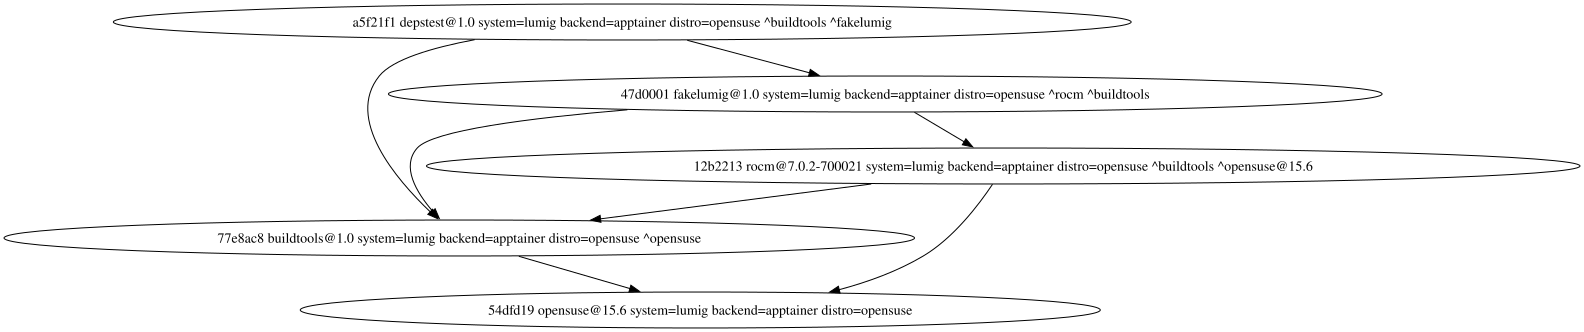

In [5]:
show_graph(graph, limit_node_info="name")

In [6]:
# Save the graph to a file
# ag.draw("dep_graph.png")